# Agent Orchestration with LangGraph
**Module 3: GenAI & Agents | ~90 min**

- Nodes and transitions
- Managing state
- Simple graph construction
- Visualization


## Setup


In [ ]:
!pip install langgraph openai --quiet


In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Optional


## 0. From loops to graphs

- Last session: we hand-wrote a `while` loop for ReAct (Thought → Action → Observation)
- **LangGraph** formalizes that same loop as nodes + edges
- Same idea, now visual, reusable, and easy to branch


## 1. Nodes & Transitions

- **Node** — a plain function: takes state in, returns updates out
- **Edge** — connects one node to the next
- `START` and `END` are fixed entry/exit points

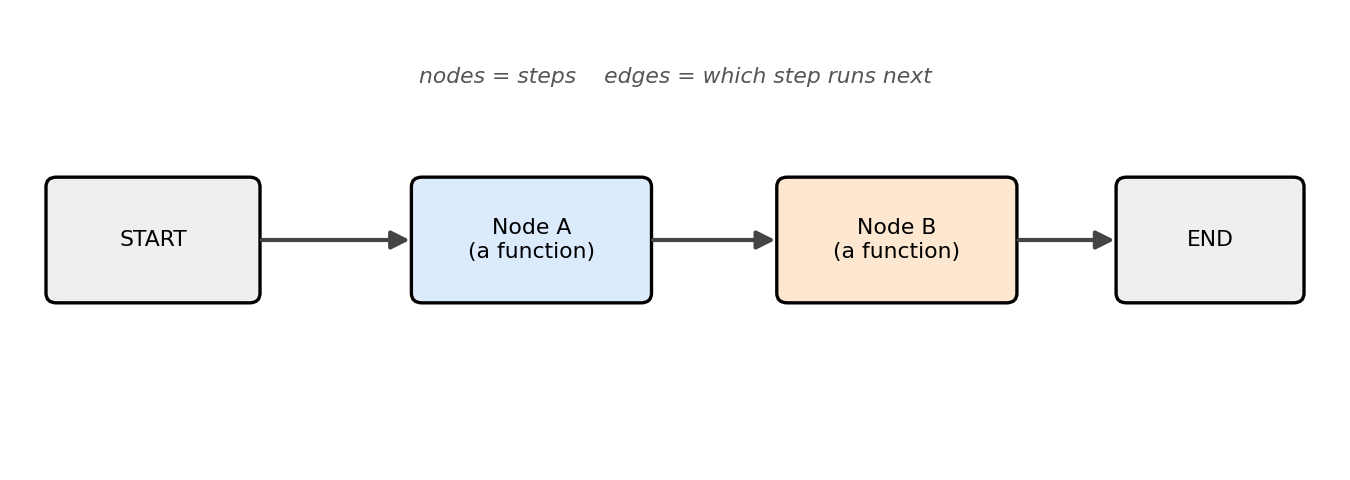


Build a 3-node linear graph: get capital → get population → double it.


In [1]:
class LinearState(TypedDict):
    capital: str
    population: str
    doubled: str

knowledge_base = {
    "capital of egypt": "Cairo",
    "population of cairo": "9500000",
}

def get_capital(state):
    return {"capital": knowledge_base["capital of egypt"]}

def get_population(state):
    key = f"population of {state['capital'].lower()}"
    return {"population": knowledge_base[key]}

def double_it(state):
    return {"doubled": str(int(state["population"]) * 2)}

graph = StateGraph(LinearState)
graph.add_node("get_capital", get_capital)
graph.add_node("get_population", get_population)
graph.add_node("double_it", double_it)
graph.add_edge(START, "get_capital")
graph.add_edge("get_capital", "get_population")
graph.add_edge("get_population", "double_it")
graph.add_edge("double_it", END)

app = graph.compile()
result = app.invoke({"capital": "", "population": "", "doubled": ""})
print(result)


{'capital': 'Cairo', 'population': '9500000', 'doubled': '19000000'}


Each node only knows its own job. The graph decides the order.


## 2. Managing State

- State = one dict shared by every node
- A node returns only the fields it changed — LangGraph merges them in
- Great for accumulating things across steps, e.g. a running log

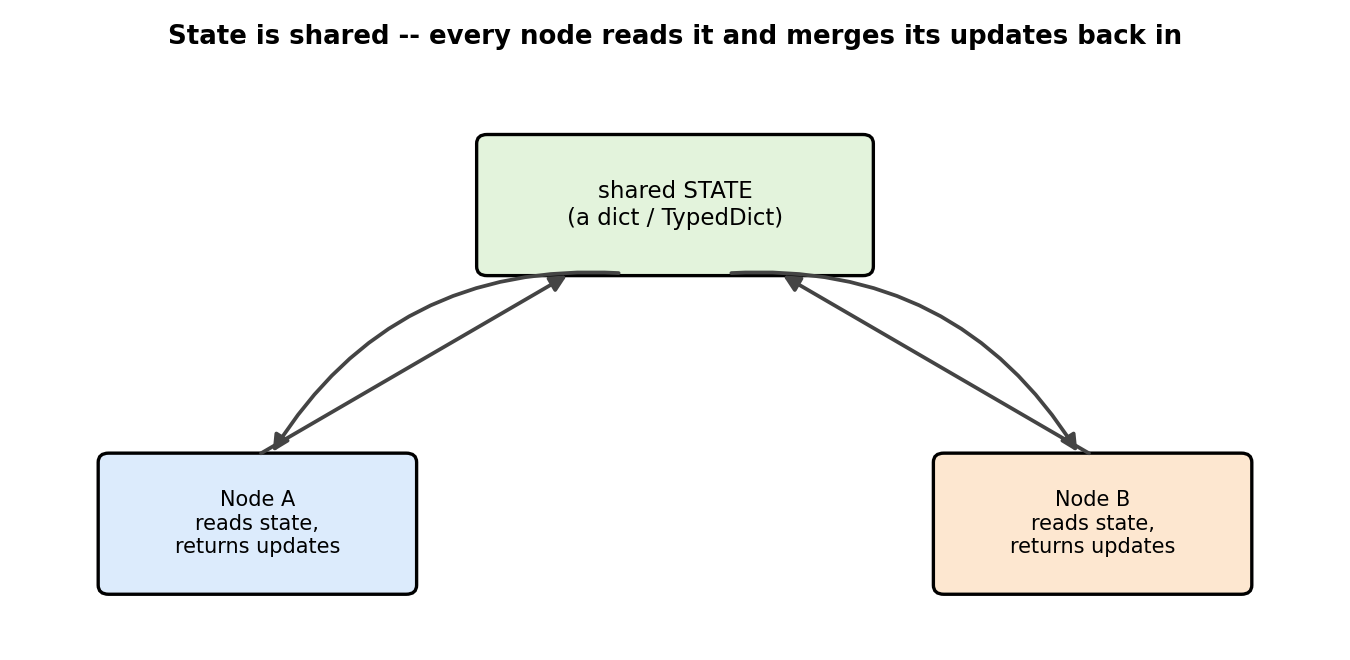


In [2]:
class LogState(TypedDict):
    capital: str
    population: str
    doubled: str
    log: list

def get_capital_logged(state):
    return {"capital": knowledge_base["capital of egypt"], "log": state["log"] + ["got capital"]}

def get_population_logged(state):
    key = f"population of {state['capital'].lower()}"
    return {"population": knowledge_base[key], "log": state["log"] + ["got population"]}

def double_it_logged(state):
    return {"doubled": str(int(state["population"]) * 2), "log": state["log"] + ["doubled it"]}

graph2 = StateGraph(LogState)
graph2.add_node("get_capital", get_capital_logged)
graph2.add_node("get_population", get_population_logged)
graph2.add_node("double_it", double_it_logged)
graph2.add_edge(START, "get_capital")
graph2.add_edge("get_capital", "get_population")
graph2.add_edge("get_population", "double_it")
graph2.add_edge("double_it", END)

app2 = graph2.compile()
result2 = app2.invoke({"capital": "", "population": "", "doubled": "", "log": []})
print(result2)


{'capital': 'Cairo', 'population': '9500000', 'doubled': '19000000', 'log': ['got capital', 'got population', 'doubled it']}


## 3. Conditional Edges: loops and branches

- A **conditional edge** picks the next node based on state — this is how loops and branches work
- Rebuild last session's ReAct loop as a graph: `reason` → route() → `act` → back to `reason`, or `stop` → `END`

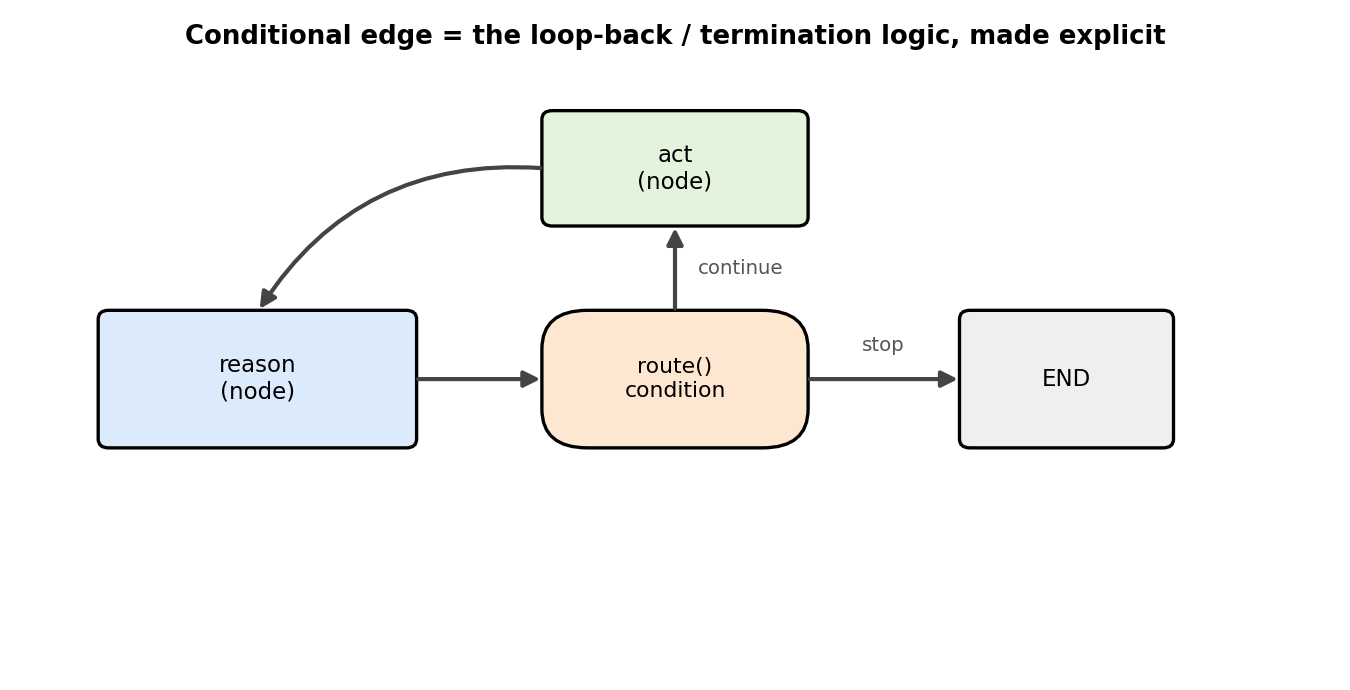


In [ ]:
from openai import OpenAI
from getpass import getpass

api_key = getpass("Enter your OpenRouter API key: ")
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)
MODEL = "deepseek/deepseek-v4-flash-0731:free"

kb_full = {
    "capital of japan": "Tokyo",
    "population of tokyo": "13960000",
}

react_system_prompt = '''You are an agent that solves problems by reasoning and acting in a loop.

You have exactly two tools:
- calculator[expression]
- lookup[key]

Reply using ONLY this format, one step at a time:

Thought: <reasoning>
Action: <calculator[...] or lookup[...]>

When done, reply:

Thought: <final reasoning>
Final Answer: <answer>
'''


In [ ]:
class AgentState(TypedDict):
    messages: list
    last_reply: str
    final_answer: Optional[str]
    step: int

def reason(state):
    response = client.chat.completions.create(model=MODEL, messages=state["messages"])
    reply = response.choices[0].message.content
    new_messages = state["messages"] + [{"role": "assistant", "content": reply}]
    final = reply.split("Final Answer:")[-1].strip() if "Final Answer:" in reply else None
    print(f"--- reason (step {state['step']+1}) ---")
    print(reply)
    return {"messages": new_messages, "last_reply": reply, "final_answer": final, "step": state["step"] + 1}

def act(state):
    action_line = [l for l in state["last_reply"].split("\n") if l.strip().startswith("Action:")][0]
    action_text = action_line.split("Action:")[-1].strip()
    if action_text.startswith("calculator["):
        observation = str(eval(action_text[len("calculator["):-1]))
    elif action_text.startswith("lookup["):
        key = action_text[len("lookup["):-1].strip().lower()
        observation = kb_full.get(key, "no info")
    else:
        observation = "unknown tool"
    print(f"Observation: {observation}\n")
    new_messages = state["messages"] + [{"role": "user", "content": f"Observation: {observation}"}]
    return {"messages": new_messages}

def route(state):
    if state["final_answer"] is not None:
        return "stop"
    if state["step"] >= 6:          # safety cap -- loop termination from last session
        return "stop"
    return "continue"


In [3]:
graph3 = StateGraph(AgentState)
graph3.add_node("reason", reason)
graph3.add_node("act", act)
graph3.add_edge(START, "reason")
graph3.add_conditional_edges("reason", route, {"continue": "act", "stop": END})
graph3.add_edge("act", "reason")
app3 = graph3.compile()

goal = "What is the population of the capital of Japan, doubled?"
result3 = app3.invoke({"messages": [{"role": "user", "content": goal}], "last_reply": "", "final_answer": None, "step": 0})

print("=" * 40)
print("FINAL ANSWER:", result3["final_answer"])


--- reason (step 1) ---
Thought: I need to find the capital of Japan first.
Action: lookup[capital of japan]
Observation: Tokyo

--- reason (step 2) ---
Thought: Now I need the population of Tokyo.
Action: lookup[population of tokyo]
Observation: 13960000

--- reason (step 3) ---
Thought: The question asks for double that number.
Action: calculator[13960000 * 2]
Observation: 27920000

--- reason (step 4) ---
Thought: I now have everything I need to answer.
Final Answer: 27,920,000
FINAL ANSWER: 27,920,000


## 4. Visualization


In [4]:
print(app3.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	reason(reason)
	act(act)
	__end__([<p>__end__</p>]):::last
	__start__ --> reason;
	act --> reason;
	reason -. &nbsp;stop&nbsp; .-> __end__;
	reason -. &nbsp;continue&nbsp; .-> act;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


Paste that output into [mermaid.live](https://mermaid.live) to see the diagram, or run this in Colab (needs internet):

```python
from IPython.display import Image
Image(app3.get_graph().draw_mermaid_png())
```


## Summary

| Concept | One-liner |
|---|---|
| Node | A function: state in, updates out |
| Edge | Connects one node to the next |
| State | Shared dict, merged after every node |
| Conditional edge | Picks the next node — this is how loops/branches work |
| Visualization | `draw_mermaid()` (text) or `draw_mermaid_png()` (image) |

**Try:**
1. Add a third tool (e.g. `uppercase[text]`) and a matching branch in `act`.
2. Change `route()`'s step cap from 6 to 2 and see it stop early.
3. Print `result3["messages"]` to see the full conversation the graph built.
